In [26]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_excel('/home/mahaputra777/pt_skp/dataset/pick_up_april_june_2026.xlsx')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Booking Date                   204 non-null    object 
 1   Modify Date                    204 non-null    object 
 2   Cancel Date                    0 non-null      float64
 3   Booking No                     204 non-null    int64  
 4   Booking Itinerary no           0 non-null      float64
 5   Channel Ref Id                 204 non-null    int64  
 6   Source                         204 non-null    object 
 7   Point Of Sale                  204 non-null    object 
 8   Payment Type                   204 non-null    object 
 9   Contact Name                   204 non-null    object 
 10  Status                         204 non-null    object 
 11  Room Type                      204 non-null    object 
 12  Package                        204 non-null    obj

In [ ]:
import pandas as pd

df = df.copy()

# ----------------------------
# Convert datetime
# ----------------------------

# Hilangkan "(WITA)"
from pandas.api.types import is_datetime64_any_dtype

if not is_datetime64_any_dtype(df["Booking Date"]):
    df["Booking Date"] = (
        df["Booking Date"]
        .astype(str)
        .str.replace(r"\s*\(.*?\)", "", regex=True)
    )

    df["Booking Date"] = pd.to_datetime(
        df["Booking Date"],
        format="%d-%b-%Y %I:%M:%S %p",
        errors="coerce"
    )

if not is_datetime64_any_dtype(df["Arrival Date"]):
    df["Arrival Date"] = pd.to_datetime(
        df["Arrival Date"],
        format="%d %b %Y",
        errors="coerce"
    )
# ----------------------------
# Booking yang masih valid
# ----------------------------

df = df[df["Status"] == "Confirmed"].copy()

# ----------------------------
# Week of Month
# ----------------------------

def week_of_month(date):
    return ((date.day - 1) // 7) + 1

df["Booking Month"] = df["Booking Date"].dt.strftime("%B")
df["Booking Week"] = df["Booking Date"].apply(week_of_month)

df["Arrival Month"] = df["Arrival Date"].dt.strftime("%B")

# Label
df["Booking Period"] = (
    df["Booking Month"] +
    " - Week " +
    df["Booking Week"].astype(str)
)

# ----------------------------
# Pickup Matrix
# ----------------------------

pickup = (
    df.pivot_table(
        index="Booking Period",
        columns="Arrival Month",
        values="Total night(s)",
        aggfunc="sum",
        fill_value=0
    )
)

# ----------------------------
# Urutan kolom (Arrival Month)
# ----------------------------
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

pickup = pickup.reindex(
    columns=[m for m in month_order if m in pickup.columns]
)

# ----------------------------
# Urutan index (Booking Period)
# ----------------------------
booking_order = []

for month in month_order:
    for week in range(1, 6):
        period = f"{month} - Week {week}"
        if period in pickup.index:
            booking_order.append(period)

pickup = pickup.reindex(booking_order)

pickup.to_excel(
    "/home/mahaputra777/pt_skp/dataset/pickup_matrix_april_june_2026.xlsx",
    index=True
)   
pickup

Arrival Month,January,February,April,May,June,July,August,September,October,December
Booking Period,,,,,,,,,,
April - Week 1,0,0,2,10,0,0,0,0,0,2
April - Week 2,0,0,0,12,6,0,0,0,0,0
April - Week 3,0,0,2,10,5,0,0,7,0,0
April - Week 4,0,0,2,14,6,2,0,2,0,0
April - Week 5,0,0,0,16,4,0,0,2,0,0
May - Week 1,0,0,0,24,10,5,0,11,0,0
May - Week 2,3,0,0,20,12,4,0,2,0,0
May - Week 3,0,0,0,2,8,3,5,0,0,0
May - Week 4,0,0,0,5,12,18,5,2,5,0


In [38]:
import calendar
from datetime import timedelta

import pandas as pd

# =====================================================
# COPY DATA
# =====================================================

df = df.copy()

# =====================================================
# CONVERT DATETIME
# =====================================================

df["Booking Date"] = (
    df["Booking Date"]
    .str.replace(r"\s*\(.*?\)", "", regex=True)
)

df["Booking Date"] = pd.to_datetime(
    df["Booking Date"],
    format="%d-%b-%Y %I:%M:%S %p",
    errors="coerce"
)

df["Arrival Date"] = pd.to_datetime(
    df["Arrival Date"],
    format="%d %b %Y",
    errors="coerce"
)

# =====================================================
# HANYA BOOKING VALID
# =====================================================

df = df[df["Status"] == "Confirmed"].copy()

# =====================================================
# MEMBUAT WEEK SETIAP BULAN
#
# Week 1 : Tanggal 1 -> Senin pertama
# Week 2 : Selasa -> Senin
# dst.
# =====================================================

def create_month_week_mapping(year: int, month: int):

    last_day = calendar.monthrange(year, month)[1]

    first_day = pd.Timestamp(year, month, 1)

    # Monday = 0
    days_until_monday = (7 - first_day.weekday()) % 7

    first_monday = first_day + timedelta(days=days_until_monday)

    week_ranges = []

    # ------------------------
    # WEEK 1
    # ------------------------

    week_ranges.append(
        (
            first_day,
            min(first_monday, pd.Timestamp(year, month, last_day))
        )
    )

    # ------------------------
    # WEEK SELANJUTNYA
    # ------------------------

    current_start = first_monday + timedelta(days=1)

    while current_start.month == month:

        current_end = current_start + timedelta(days=6)

        if current_end.month != month:
            current_end = pd.Timestamp(year, month, last_day)

        week_ranges.append((current_start, current_end))

        current_start = current_end + timedelta(days=1)

    mapping = {}

    for week_no, (start, end) in enumerate(week_ranges, start=1):

        label = (
            f"Week {week_no} "
            f"({start.strftime('%d %b')} - {end.strftime('%d %b')})"
        )

        current = start

        while current <= end:

            mapping[current.date()] = {
                "week": week_no,
                "label": label
            }

            current += timedelta(days=1)

    return mapping


# =====================================================
# MEMBUAT MAPPING SEMUA BULAN
# =====================================================

all_mapping = {}

months = (
    df["Booking Date"]
    .dt.to_period("M")
    .drop_duplicates()
    .sort_values()
)

for period in months:

    all_mapping.update(
        create_month_week_mapping(
            period.year,
            period.month
        )
    )

# =====================================================
# TAMBAH KOLOM WEEK
# =====================================================

df["Booking Month"] = df["Booking Date"].dt.strftime("%B")

df["Arrival Month"] = df["Arrival Date"].dt.strftime("%B")

df["Booking Week"] = (
    df["Booking Date"]
    .dt.date
    .map(lambda x: all_mapping[x]["week"])
)

df["Week Detail"] = (
    df["Booking Date"]
    .dt.date
    .map(lambda x: all_mapping[x]["label"])
)

df["Booking Period"] = (
    df["Booking Month"]
    + " - "
    + df["Week Detail"]
)

# =====================================================
# PICKUP MATRIX
# =====================================================

pickup = (
    df.pivot_table(
        index="Booking Period",
        columns="Arrival Month",
        values="Total night(s)",
        aggfunc="sum",
        fill_value=0
    )
)

# =====================================================
# URUTAN BULAN
# =====================================================

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

pickup = pickup.reindex(
    columns=[m for m in month_order if m in pickup.columns]
)

# =====================================================
# URUTAN WEEK
# =====================================================

booking_order = []

for period in months:

    mapping = create_month_week_mapping(
        period.year,
        period.month
    )

    added = set()

    for value in mapping.values():

        label = (
            period.strftime("%B")
            + " - "
            + value["label"]
        )

        if label not in added:
            booking_order.append(label)
            added.add(label)

pickup = pickup.reindex(booking_order)

# =====================================================
# EXPORT
# =====================================================

output_path = "/home/mahaputra777/pt_skp/dataset/pickup_matrix_april_june_2026.xlsx"

pickup.to_excel(output_path)

print(f"Berhasil disimpan ke:\n{output_path}")

# =====================================================
# TAMPILKAN
# =====================================================

pickup

AttributeError: Can only use .str accessor with string values!

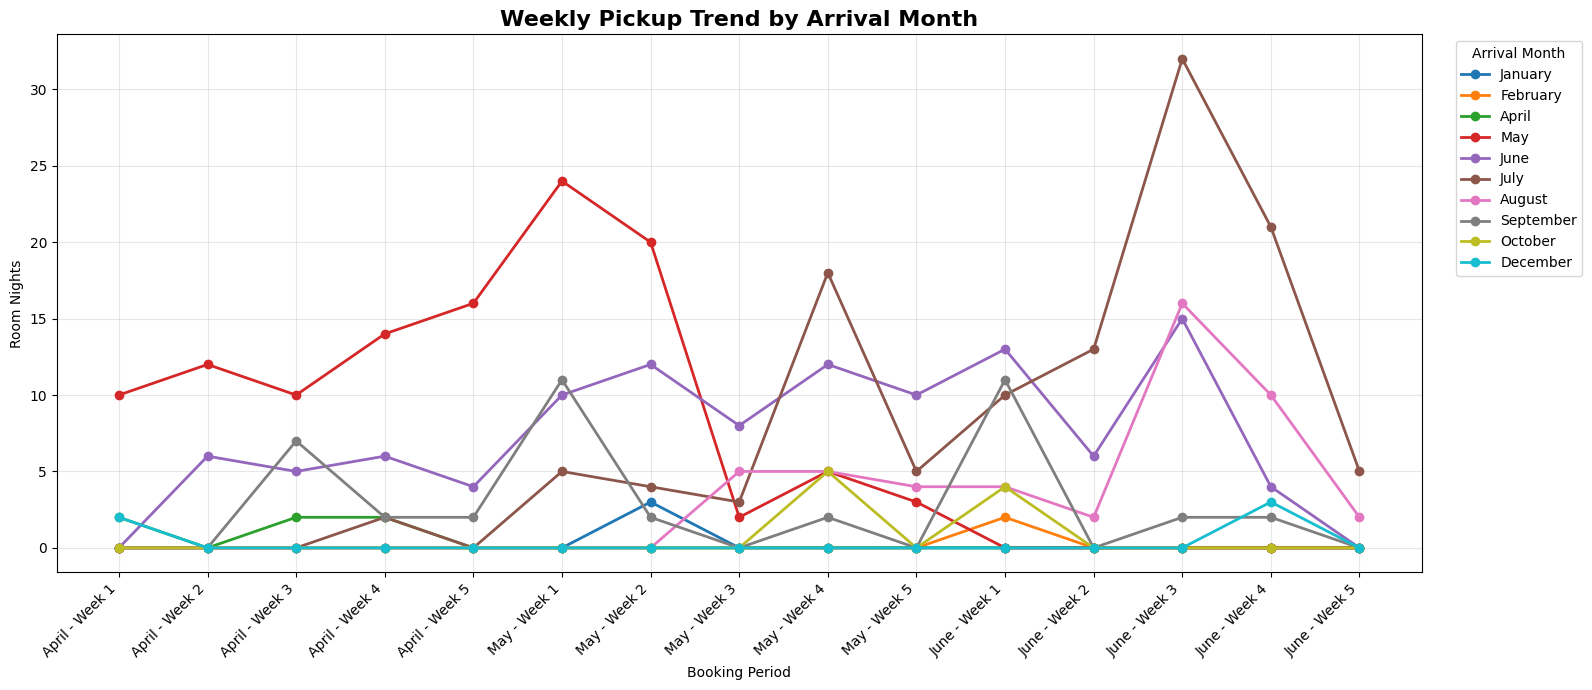

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,7))

for month in pickup.columns:
    plt.plot(
        pickup.index,
        pickup[month],
        marker="o",
        linewidth=2,
        label=month
    )

plt.title("Weekly Pickup Trend by Arrival Month", fontsize=16, fontweight="bold")
plt.xlabel("Booking Period")
plt.ylabel("Room Nights")

plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    title="Arrival Month"
)

plt.tight_layout()
plt.show()

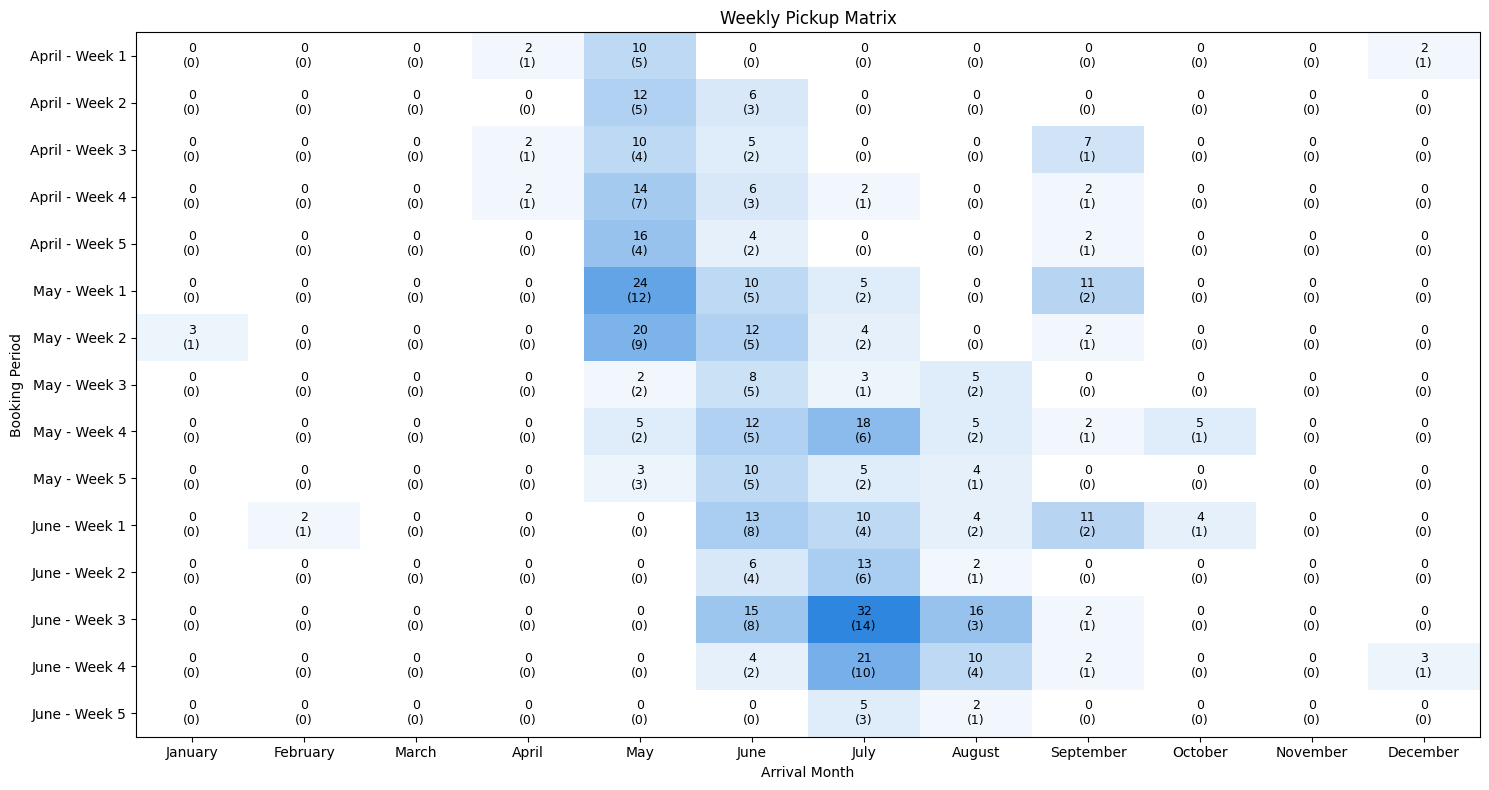

In [35]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

values = room_nights.values.astype(float)

# Normalisasi 0-1
norm = plt.Normalize(values.min(), values.max())

# Pilih warna dasar
base_color = mcolors.to_rgba("#2E86DE")   # Biru

rgba = np.zeros((values.shape[0], values.shape[1], 4))

rgba[..., 0] = base_color[0]
rgba[..., 1] = base_color[1]
rgba[..., 2] = base_color[2]

# Alpha = hasil normalisasi
rgba[..., 3] = norm(values)

fig, ax = plt.subplots(figsize=(15,8))

ax.imshow(rgba, aspect="auto")

# Label
ax.set_xticks(np.arange(len(room_nights.columns)))
ax.set_xticklabels(room_nights.columns)

ax.set_yticks(np.arange(len(room_nights.index)))
ax.set_yticklabels(room_nights.index)

# Isi angka
for i in range(room_nights.shape[0]):
    for j in range(room_nights.shape[1]):

        rn = int(room_nights.iloc[i, j])
        res = int(reservations.iloc[i, j])

        ax.text(
            j,
            i,
            f"{rn}\n({res})",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

plt.title("Weekly Pickup Matrix")
plt.xlabel("Arrival Month")
plt.ylabel("Booking Period")

plt.tight_layout()
plt.show()